In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd
from tensorflow import keras

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import time
import matplotlib
import matplotlib.ticker as mticker
import warnings


2025-09-08 15:07:44.661730: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI AVX512_BF16
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-08 15:07:44.837607: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# HOME = "/scistor/ivm/the410/"

HOME = "/home/thappe/" #snellius

In [3]:
os.chdir(f"{HOME}HeaT")
#sys.path.append(os.path.expanduser('/home/thappe/HeaT'))

from HeaT.TFrecord_utils_ERA_v2 import *
from HeaT.reconstruction import *

In [4]:
os.chdir(f"{HOME}/VAE3D/autoencoder_notebooks/LatentSpace/") #if IVM /P1/

from model.autoencoder_3d_model_v1 import CVAE
# from model.utils_3d import _parse_function_full, _parse_function

In [5]:
pwd

'/gpfs/home4/thappe/VAE3D/autoencoder_notebooks/LatentSpace'

In [6]:
### GLOBAL VARIABLES IVM

os.chdir(HOME)

#IVM 
# data_path = "/scistor/ivm/the410/PAPER3"

#SNELLIUS
data_path = "/home/thappe/data/VAE_MODEL"
tf_record_path = "/home/thappe/data/tf_records/"

In [7]:
ls data/VAE_MODEL

entire_model_VAE/
ERA5_t2m_dynamic_encoded_heatwaves_L128.csv
ERA5_t2m_dynamic_heatwaves_dates.csv
ERA5_t2m_encoded_heatwaves_L128.csv
ERA5_t2m_heatwaves_dates.csv
ERA5_t2m_minus_thermo_encoded_heatwaves_L128.csv
ERA5_t2m_minus_thermo_heatwaves_dates.csv
GMM.pkl
Kmeanseucl.pkl
LENTIS_classes_VAE_L128_1000epochs.csv
LENTIS_Heatwave_means_VAE_L128_1000epochs.csv
VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


## LOADING DATA  ERA5

In [8]:
t2m_name = "t2m_minus_thermo" 

assert t2m_name in ["t2m", "t2m_dynamic", "t2m_minus_thermo"], "data not available for this var"

tf_record_file = f"{tf_record_path}/TF_record_ERA5_{t2m_name}_1940-2023_standardization_cut.tfrecord"

In [9]:
data = load_tfrecords_ERA5(tf_record_file)

2025-09-08 15:07:52.338767: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-09-08 15:07:52.338844: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (tcn745.local.snellius.surf.nl): /proc/driver/nvidia/version does not exist
2025-09-08 15:07:52.340192: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI AVX512_BF16
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
#Get a sample to use for visualisation during training
data_testbatch = data.map(parse_function_full_era5).take(1) #selecting only one for visualisation

data_parsed = data.map(parse_function_full_era5)

In [11]:
data_testbatch


for element in data_testbatch.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    date = str(element[1]) + "_" + str(element[2]) + "_" + str(element[3]) 

## LOADING DATA LENTIS

In [12]:
ls /projects/einf4738/tf_records/files

TF_record_correctmask_ensemble101_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble102_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble103_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble104_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble105_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble106_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble107_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble108_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble109_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble110_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble111_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble112_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble113_NAext2_standardization_cut_noR

In [18]:
os.chdir(f"{HOME}/VAE3D/autoencoder_notebooks/LatentSpace/") #if IVM /P1/

from model.utils_3d import _parse_function_full, _parse_function

In [19]:
def load_tfrecords_LENTIS(ensembles, norm_method='normalization'):
#     os.chdir(path)
    filenames = []
    if norm_method == 'standardized':
      norm_method = "0"
    for ens in ensembles:
        filenames.append(f"/projects/einf4738/tf_records/files/TF_record_correctmask_ensemble{ens}_NAext2_{norm_method}_noRSDS.tfrecord")
    data = tf.data.TFRecordDataset(filenames)
    return data

In [20]:
#load tf_records from lentis


#LOAD data from records
data_train_raw = load_tfrecords_LENTIS(np.arange(101,115,1), "standardization_cut")
data_val_raw = load_tfrecords_LENTIS(np.arange(115,117,1), "standardization_cut")


data_parsed_train = data_train_raw.map(_parse_function)
data_parsed_val = data_val_raw.map(_parse_function)

## reconstruction and plottin

In [23]:
pwd

'/gpfs/home4/thappe'

In [12]:
VAE_model = (128, f"{data_path}/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5")

In [17]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

/home/thappe/data/VAE_MODEL/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


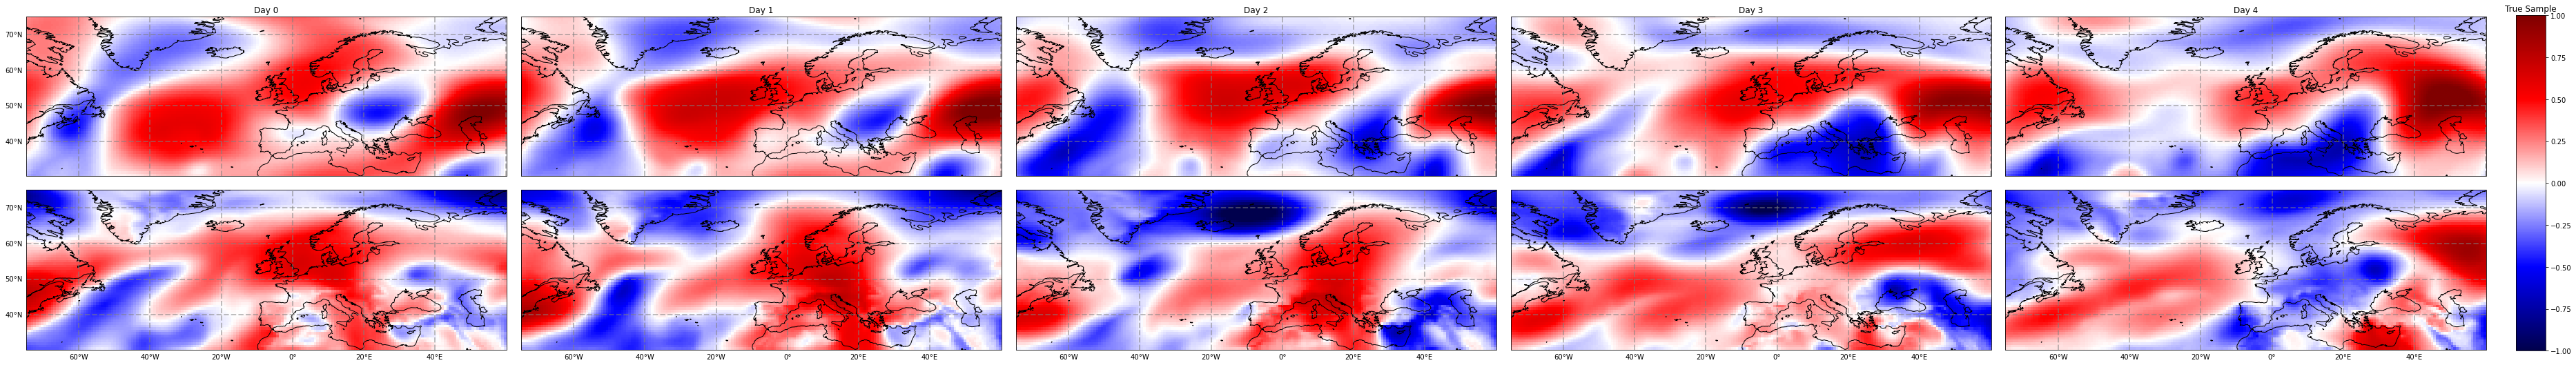

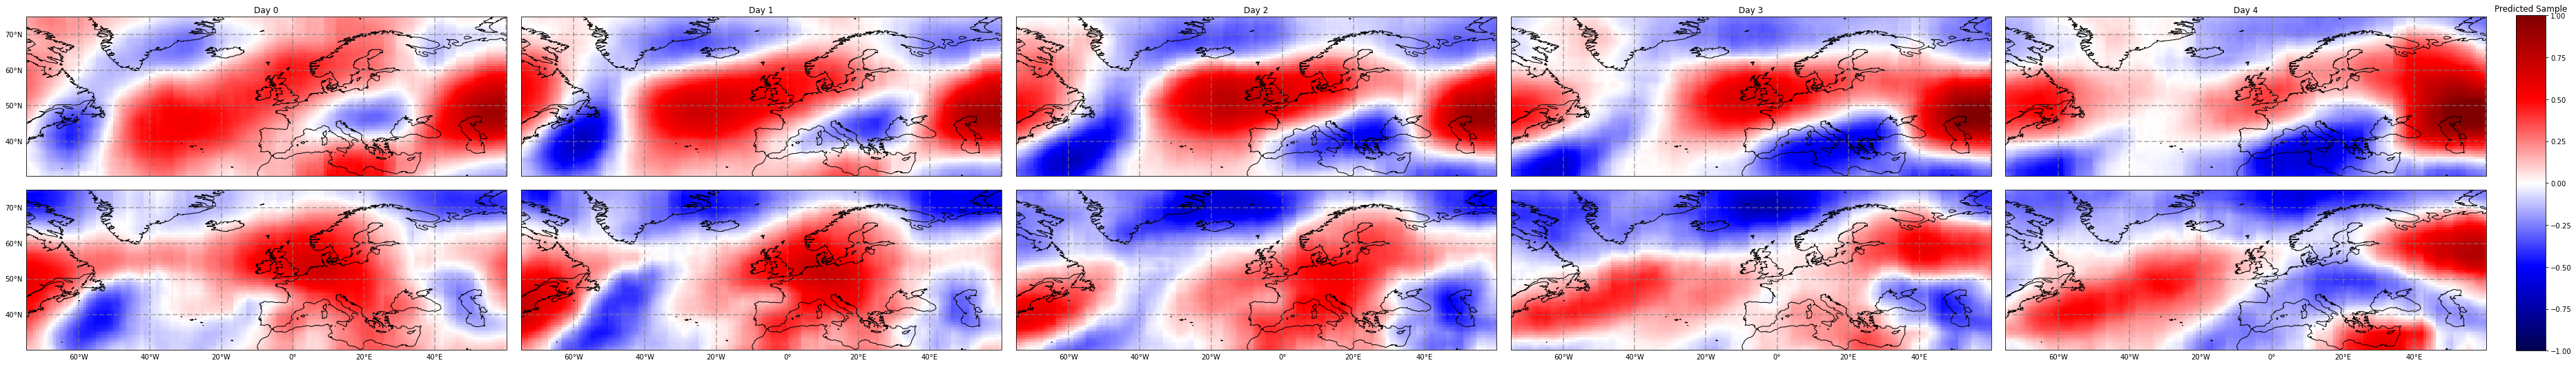

In [19]:
print(VAE_model[1])

%matplotlib inline

reconstruct_VAE_ERA5(VAE_model[1], VAE_model[0], data_testbatch)

# Get reconstruction error (R2 and MSE)

In [13]:
print(VAE_model[1])

r2_era5 = get_r2_reconstructed_ERA5(VAE_model[1], VAE_model[0], data_parsed)


/home/thappe/data/VAE_MODEL/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


In [73]:
len(r2_era5)

739

In [18]:
np.mean(r2_era5)


0.8890415122210358

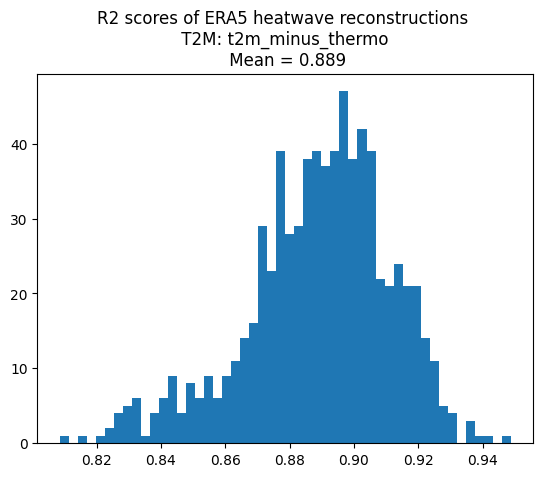

In [19]:
plt.hist(r2_era5, bins=50)
plt.title(f"R2 scores of ERA5 heatwave reconstructions \n T2M: {t2m_name} \n Mean = {round(np.mean(r2_era5), 3)}")
plt.show()

In [29]:
MSE_era5 = get_MSE_reconstructed_ERA5(VAE_model[1], VAE_model[0], data_parsed)

In [32]:
len(MSE_era5)

739

0.011


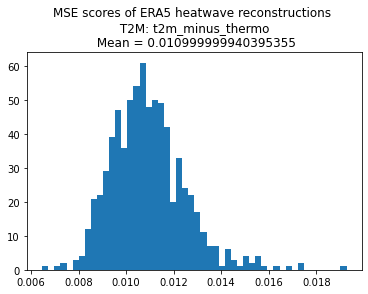

In [40]:
plt.clf()

plt.hist(MSE_era5, bins=50)
mean_rounded = round(np.mean(MSE_era5), 3)
print(mean_rounded)
plt.title(f"MSE scores of ERA5 heatwave reconstructions \n T2M: {t2m_name} \n Mean = {mean_rounded}")
plt.show()

##### how does this compare to the LENTIS data?

In [21]:
MSE_LENTIS_val = get_MSE_reconstructed_ERA5(VAE_model[1], VAE_model[0], data_parsed_val)
r2_LENTIS_val = get_r2_reconstructed_ERA5(VAE_model[1], VAE_model[0], data_parsed_val)


0.01


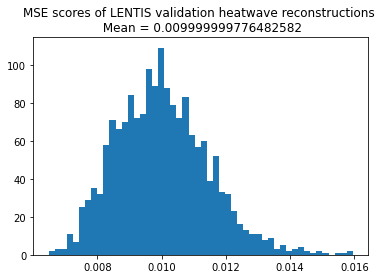

In [66]:
%matplotlib inline
plt.clf()

plt.hist(MSE_LENTIS_val, bins=50)
mean_rounded = round(np.mean(MSE_LENTIS_val), 3)
print(mean_rounded)
plt.title(f"MSE scores of LENTIS validation heatwave reconstructions \n Mean = {mean_rounded}")
plt.show()

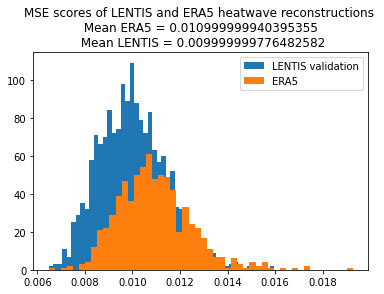

In [69]:
plt.hist(MSE_LENTIS_val, bins=50, label="LENTIS validation")
lentis_mean_rounded = round(np.mean(MSE_LENTIS_val), 3)

plt.hist(MSE_era5, bins=50, label="ERA5")
era5_mean_rounded = round(np.mean(MSE_era5), 3)

plt.title(f"MSE scores of LENTIS and ERA5 heatwave reconstructions \n Mean ERA5 = {era5_mean_rounded} \n Mean LENTIS = {lentis_mean_rounded}")

plt.legend()
plt.show()

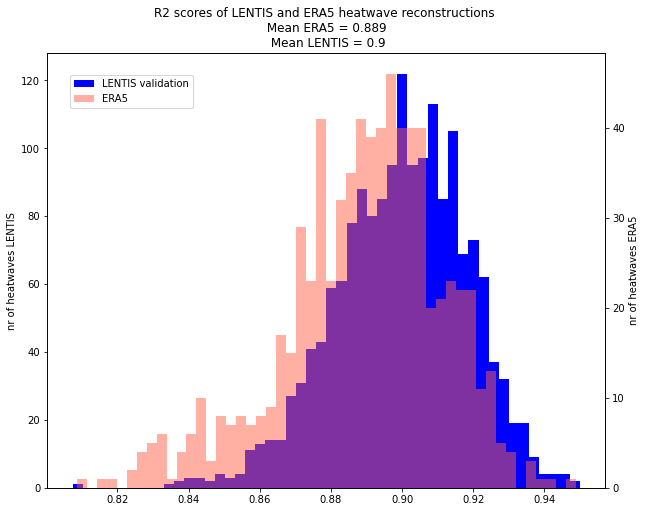

In [64]:
%matplotlib inline

fig, ax1 = plt.subplots(figsize=(10,8))

ax1.hist(r2_LENTIS_val, bins=50, color ="blue", label="LENTIS validation")
ax1.set_ylabel("nr of heatwaves LENTIS")
lentis_mean_rounded = round(np.mean(r2_LENTIS_val), 3)

ax2 = ax1.twinx()
ax2.hist(r2_era5, bins=50, label="ERA5", color="tomato", alpha=0.5)
ax2.set_ylabel("nr of heatwaves ERA5")
era5_mean_rounded = round(np.mean(r2_era5), 3)

plt.title(f"R2 scores of LENTIS and ERA5 heatwave reconstructions \n Mean ERA5 = {era5_mean_rounded} \n Mean LENTIS = {lentis_mean_rounded}")

fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.85))
plt.show()

# How do other statics of the samples compare, between LENTIS and ERA5?

of both the input and the means

In [20]:
VAE_model[1], VAE_model[0]

('/home/thappe/data/VAE_MODEL/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5',
 128)

In [21]:
model_file, L = VAE_model[1], VAE_model[0]
data_parsed = data_parsed #era5 or lentis 

###
regularizer = tf.keras.regularizers.L2(0.2)
model = CVAE(L, filter_scaling=4)
model.built = True
model.load_weights(f"{model_file}")

warnings.filterwarnings("ignore")


test_sample = np.zeros((1, 192, 64, 5, 2)) 

stream_list = []
psl_list = []

for element in data_parsed.as_numpy_iterator():
    test_sample[0] = element[0]
    stream_list.append(test_sample[0, :, :, :, 0])
    psl_list.append(test_sample[0, :, :, :, 1])


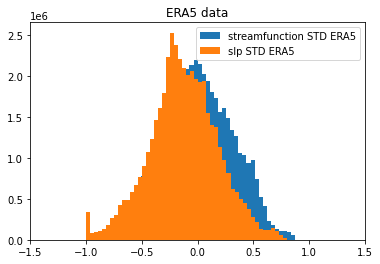

In [103]:
plt.hist(np.array(stream_list).flatten(), bins=50, label="streamfunction STD ERA5")
plt.hist(np.array(psl_list).flatten(), bins=50, label="slp STD ERA5")

plt.xlim(-1.5,1.5)
plt.legend()
plt.title("ERA5 data")
plt.show()


In [24]:
mean_stream = np.array(stream_list).mean(axis=0)
mean_psl = np.array(psl_list).mean(axis=0)

In [28]:
mean_stream.shape

(192, 64, 5)

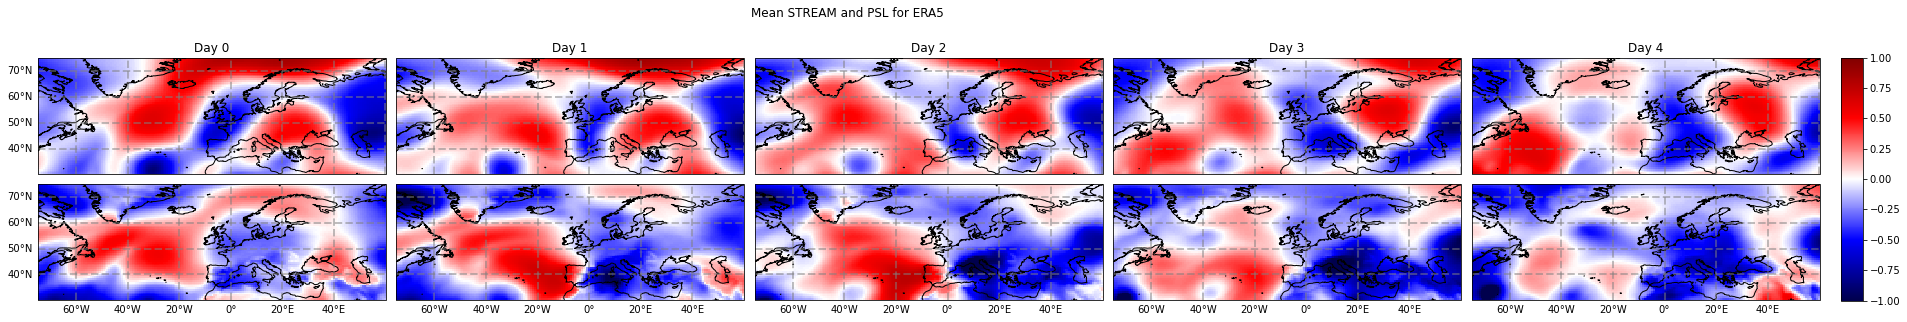

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(30, 5))

for t in range(5):
    stream = np.transpose(mean_stream[:, :, t])
    psl    = np.transpose(mean_psl[:, :, t])

    #plot stream function
    ax = plt.subplot(2, 5, t + 1, projection=ccrs.PlateCarree())
    cs = ax.pcolormesh(LONS, LATS, stream, transform=ccrs.PlateCarree(),
                       cmap="seismic", vmin=-1, vmax=1)
    ax.coastlines()
    ax.set_title("Day {}".format(t))
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gl.xlabels_top    = False
    gl.xlabels_bottom = False
    gl.ylabels_right  = False
    if t == 0:
      gl.ylabels_left = True
    else:
      gl.ylabels_left = False

    #plot sea level pressure
    ax = plt.subplot(2, 5, t + 6, projection=ccrs.PlateCarree())
    cs = ax.pcolormesh(LONS, LATS, psl, transform=ccrs.PlateCarree(),
                       cmap="seismic", vmin=-1, vmax=1)
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.FixedLocator([-60, -40, -20, 0, 20, 40])
    gl.xlabels_top   = False
    gl.ylabels_right = False
    if t == 0:
      gl.ylabels_left = True
    else:
      gl.ylabels_left = False    

h_space = -0.14
#w_space = h_space * fig_height / fig_width
w_space = 0.03
fig.subplots_adjust(wspace=w_space, hspace=h_space)
fig.subplots_adjust(right=0.95)
ax_cbar = fig.add_axes([0.96, 0.165, 0.01, 0.675])
fig.colorbar(cs, cax=ax_cbar)

plt.suptitle("Mean STREAM and PSL for ERA5")

plt.show()


In [39]:
model_file, L = VAE_model[1], VAE_model[0]
data_parsed = data_parsed_val #era5 or lentis 

###
regularizer = tf.keras.regularizers.L2(0.2)
model = CVAE(L, filter_scaling=4)
model.built = True
model.load_weights(f"{model_file}")

warnings.filterwarnings("ignore")


test_sample = np.zeros((1, 192, 64, 5, 2)) 

stream_list = []
psl_list = []

for element in data_parsed.as_numpy_iterator():
    test_sample[0] = element[0]
    stream_list.append(test_sample[0, :, :, :, 0])
    psl_list.append(test_sample[0, :, :, :, 1])


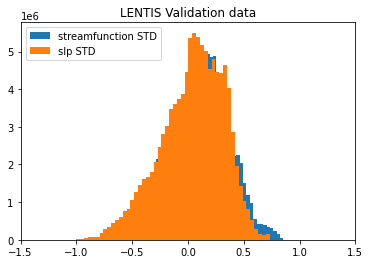

In [105]:
plt.hist(np.array(stream_list).flatten(), bins=50, label="streamfunction STD")
plt.hist(np.array(psl_list).flatten(), bins=50, label="slp STD")

plt.xlim(-1.5,1.5)
plt.legend()
plt.title("LENTIS Validation data")
plt.show()


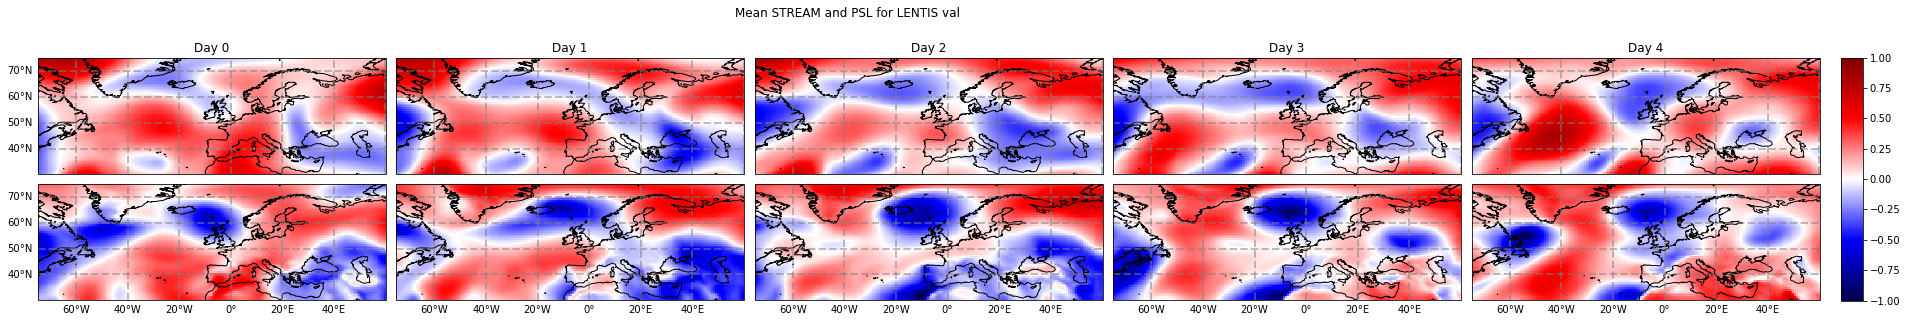

In [40]:
mean_stream = np.array(stream_list).mean(axis=0)
mean_psl = np.array(psl_list).mean(axis=0)


fig, axes = plt.subplots(2, 5, figsize=(30, 5))

for t in range(5):
    stream = np.transpose(mean_stream[:, :, t])
    psl    = np.transpose(mean_psl[:, :, t])

    #plot stream function
    ax = plt.subplot(2, 5, t + 1, projection=ccrs.PlateCarree())
    cs = ax.pcolormesh(LONS, LATS, stream, transform=ccrs.PlateCarree(),
                       cmap="seismic", vmin=-1, vmax=1)
    ax.coastlines()
    ax.set_title("Day {}".format(t))
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gl.xlabels_top    = False
    gl.xlabels_bottom = False
    gl.ylabels_right  = False
    if t == 0:
      gl.ylabels_left = True
    else:
      gl.ylabels_left = False

    #plot sea level pressure
    ax = plt.subplot(2, 5, t + 6, projection=ccrs.PlateCarree())
    cs = ax.pcolormesh(LONS, LATS, psl, transform=ccrs.PlateCarree(),
                       cmap="seismic", vmin=-1, vmax=1)
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.FixedLocator([-60, -40, -20, 0, 20, 40])
    gl.xlabels_top   = False
    gl.ylabels_right = False
    if t == 0:
      gl.ylabels_left = True
    else:
      gl.ylabels_left = False    

h_space = -0.14
#w_space = h_space * fig_height / fig_width
w_space = 0.03
fig.subplots_adjust(wspace=w_space, hspace=h_space)
fig.subplots_adjust(right=0.95)
ax_cbar = fig.add_axes([0.96, 0.165, 0.01, 0.675])
fig.colorbar(cs, cax=ax_cbar)

plt.suptitle("Mean STREAM and PSL for LENTIS val")

plt.show()


# encoding heatwaves and dates and saving to csv 



In [20]:
heatwave_means = get_heatwave_means(VAE_model[1], VAE_model[0], data_parsed)

In [21]:
## save the means to csv

o = np.ones((VAE_model[0])) #shape of dimensions
nested_lists = [o]
for i in range(len(heatwave_means)):
    nested_lists.append(list(heatwave_means[i]))

import csv
with open(f'{data_path}/ERA5_{t2m_name}_encoded_heatwaves_L{VAE_model[0]}.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(nested_lists)  

In [22]:
#save dates to csv

from datetime import date
dates = []
dates_iso = []
for element in data_parsed.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    iso_date = date(element[1], element[2], element[3]).isoformat() #year, month, date 
    dates_iso.append([iso_date])
    date_date = date.fromisoformat(iso_date) #to datetime object 
    dates.append(date_date)

In [23]:
with open(f'{data_path}/ERA5_{t2m_name}_heatwaves_dates.csv', 'w', newline='') as f:
    writer = csv.writer(f, delimiter="-")
    writer.writerows(dates_iso) 